# Detección de Inyecciones SQL mediante técnicas de procesamiento de lenguaje natural y aprendizaje automático

## Introducción
Por Gonzalo Benito, Lic. en Sistemas de Información, Universidad Nacional de Luján, Argentina.

Este trabajo propone desarrollar un sistema de detección de ataques de Inyección SQL utilizando técnicas de procesamiento de lenguaje natural (NLP) y algoritmos de machine learning. Se empleó un dataset obtenido de Kaggle que contiene sentencias SQL etiquetadas como peligrosas o benignas. La metodología incluyó la transformación de las sentencias en vectores mediante una matriz TF-IDF sobre n-gramas de caracteres y palabras, seguida de la aplicación de algoritmos de clasificación como Support Vector Machines (SVM), Random Forest y Logistic Regression. El objetivo fue evaluar y comparar el desempeño de los modelos mediante métricas de precisión, recall y F1-score, y **demostrar si es posible la detección de ataques de inyección SQL mediante técnicas de Machine Learning**.

#### Detalles de lo que se incluirá en este trabajo
La metodología seguirá un enfoque basado en una matriz TF-IDF (matriz dispersa o *sparse*) sobre n-gramas de caracteres (y de palabras también). Con este método, cada sentencia se transforma en un vector o fila de la matriz; las columnas corresponden a n-gramas de longitud fija (por ejemplo, de 3 a 5 caracteres) o a combinaciones de palabras (más especificamente combinaciones de *tokens*, que llamaremos unigramas, bigramas o trigramas); y los valores de cada celda reflejan la frecuencia (o el peso TF-IDF, según la configuración utilizada) de cada n-grama en la sentencia. Se probarán diferentes configuraciones para los algoritmos usados durante la ingeniería de características (Feature Engineering), y se evaluarán las distintas matrices dispersas obtenidas con algoritmos de clasificación, como Support Vector Machines (SVM), Random Forest y Logistic Regression. El objetivo es evaluar y comparar el desempeño de las distintas configuraciones de los modelos, mediante las métricas de precisión más usadas, y demostrar si es posible la detección de ataques de inyección SQL mediante técnicas de Machine Learning.

## Descripción del dataset
El dataset utilizado es 'SQL Injection Dataset' de Syed Saqlain Hussain (Kaggle), con 30.920 filas y dos columnas principales: `Sentence` (consulta SQL o texto) y `Label` (0=benigna, 1=inyección).

| Atributo | Tipo | Descripción |
| -------- | ---- | ----------- |
| Sentence | texto | Consulta SQL completa o texto |
| Label | categórica | 0 = no inyección, 1 = inyección SQL |

De la variable Sentence se obtendrá el conjunto de features durante la fase de Feature Engineering, con clases como CountVectorizer, TfidfVectorizer, o Word2vec.

Link del dataset: https://www.kaggle.com/datasets/syedsaqlainhussain/sql-injection-dataset

## Instalación de librerías necesarias

In [1]:
# Dependencias
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
%pip install numpy==1.26.4
%pip install imbalanced-learn

import pandas as pd
import gc  # Para gestión de memoria

# Configuración para optimizar memoria
pd.options.mode.copy_on_write = True  # Evita copias innecesarias en pandas

print("Bibliotecas importadas correctamente")
print("IMPORTANTE: Este notebook está optimizado para bajo consumo de memoria")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Bibliotecas importadas correctamente
IMPORTANTE: Este notebook está optimizado para bajo consumo de memoria
Bibliotecas importadas correctamente
IMPORTANTE: Este notebook está optimizado para bajo consumo de memoria


### Importación del dataset y selección de features

In [2]:
import pandas as pd

data: pd.DataFrame = pd.read_csv(
    "./data/SQLiV3.csv"
)  # El dataset debe tener columnas 'Sentence' y 'Label'
data

,Sentence,Label,Unnamed: 2,Unnamed: 3
0,""" or pg_sleep ( __TIME__ ) --",1,NaN,NaN
1,create user name identified by pass123 tempora...,NaN,1,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1,NaN,NaN
3,select * from users where id = '1' or @ @1 ...,1,NaN,NaN
4,"select * from users where id = 1 or 1#"" ( ...",1,NaN,NaN
...,...,...,...,...
30914,DELETE FROM door WHERE grow = 'small',0,NaN,NaN
30915,DELETE FROM tomorrow,0,NaN,NaN
30916,SELECT wide ( s ) FROM west,0,NaN,NaN
30917,SELECT * FROM ( SELECT slide FROM breath ),0,NaN,NaN


In [3]:
data = data[["Sentence", "Label"]].copy()  # Seleccionar solo las columnas necesarias
data["Sentence"] = data["Sentence"].astype(str)
data["length"] = data["Sentence"].apply(len)
data

,Sentence,Label,length
0,""" or pg_sleep ( __TIME__ ) --",1,33
1,create user name identified by pass123 tempora...,NaN,89
2,AND 1 = utl_inaddr.get_host_address ( ...,1,218
3,select * from users where id = '1' or @ @1 ...,1,90
4,"select * from users where id = 1 or 1#"" ( ...",1,85
...,...,...,...
30914,DELETE FROM door WHERE grow = 'small',0,37
30915,DELETE FROM tomorrow,0,20
30916,SELECT wide ( s ) FROM west,0,28
30917,SELECT * FROM ( SELECT slide FROM breath ),0,44


## Preprocesamiento

### Limpieza de missing values y ruido

In [4]:
# Eliminar filas donde 'Sentence' es NaN
data = data.dropna(subset=["Sentence"])

# Me quedo solo con las clases 0 y 1 (por si hay algún otro valor en 'Label', como un string)
data = data[data["Label"].isin(["0", "1"])]

## Análisis exploratorio de datos (EDA)
Exploramos la distribución de clases y longitud de sentencias.

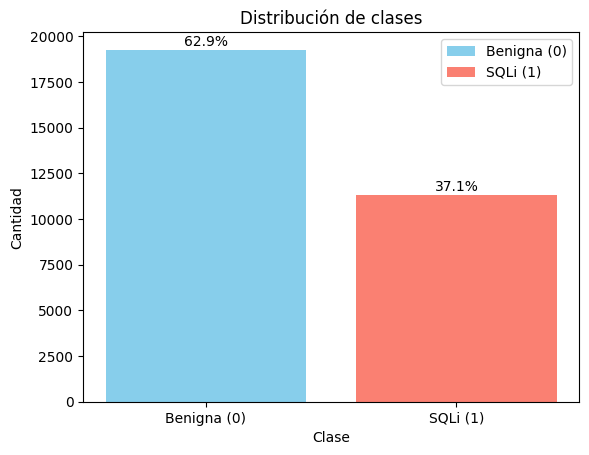

In [5]:
# Distribución de clases
import matplotlib.pyplot as plt

value_counts = data["Label"].value_counts()
percentage = (value_counts / value_counts.sum()) * 100
labels = ["Benigna (0)", "SQLi (1)"]

fig, axes = plt.subplots()
bars = axes.bar(labels, value_counts, color=["skyblue", "salmon"], label=labels)

# Texto de porcentaje arriba de cada barra
for bar, pct in zip(bars, percentage):
    axes.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{pct:.1f}%",
        ha="center",
        fontsize=10,
    )

axes.set_title("Distribución de clases")
axes.set_xlabel("Clase")
axes.set_ylabel("Cantidad")
axes.legend()
plt.show()

Las clases están desbalanceadas. La clase mayoritaria es la 0 (sentencias benignas). Recurriremos a técnicas de balanceo para solucionar este problema.

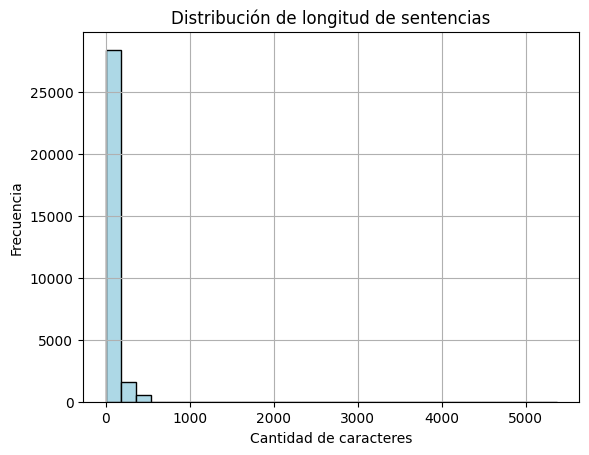

Cantidad de caracteres de la sentencia más larga: 5370


,Sentence,Label,length
19341,de]]> </email_address> <find_account_answer...,0,5370
19667,SELECT wp_posts.* FROM wp_posts LEFT JOIN wp_p...,0,559
19663,SELECT wp_posts.ID FROM wp_posts LEFT JOIN wp_...,0,529
9780,1'|| ( select 'rjis' from dual where 7696 =...,1,456
7270,"-6475"" ) ) ) or 4144 = ( selec...",1,455
...,...,...,...
628,!,1,1
19312,0,1,1
438,?,1,1
106,s,1,1


In [6]:
data["length"].hist(bins=30, color="lightblue", edgecolor="black")
plt.title("Distribución de longitud de sentencias")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")
plt.show()

print(f"Cantidad de caracteres de la sentencia más larga: {data['length'].max()}")
data_sort_by_length = data.sort_values(by="length", ascending=False)
data_sort_by_length

Vemos que la sentencia 19341 tiene una longitud atípica, 10 veces mayor que la segunda sentencia más larga. Esta es benigna. La eliminaremos del dataset por ser un outlier. Luego volvemos a mostrar el histograma de longitudes de sentencia.

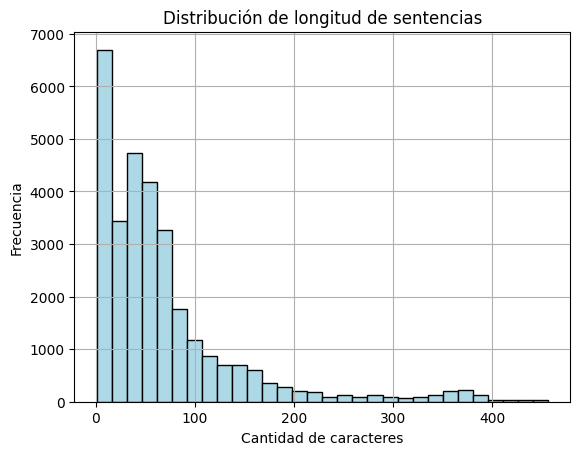

In [7]:
data = data[data["length"] <= 500]
data["length"].max()

data["length"].hist(bins=30, color="lightblue", edgecolor="black")
plt.title("Distribución de longitud de sentencias")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")
plt.show()

## Feature Engineering
Se exploran dos enfoques: TF-IDF y Word2Vec (este último en otro notebook). No se tendrán en cuenta los espacios en blanco de las sentencias.

In [8]:
# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# CONFIGURACIÓN OPTIMIZADA PARA MEMORIA
MAX_FEATURES = 15000  # Limitar número de características para reducir RAM

print("APLICANDO TF-IDF CON OPTIMIZACIÓN DE MEMORIA:")
print(f"- Limitando a máximo {MAX_FEATURES:,} características")
print("- Manteniendo matriz sparse (no conversión a denso)")

tfidf = TfidfVectorizer(
    ngram_range=(3, 3),
    analyzer="char_wb",
    min_df=3,
    max_features=MAX_FEATURES,  # ✓ LIMITAR CARACTERÍSTICAS PARA AHORRAR RAM
    lowercase=True,
    strip_accents="ascii",
    use_idf=False,
    stop_words="english",
    token_pattern=r"\b\w+\b",
)
"""
usar use_idf=False para no penalizar por IDF
usar max_features=integer para limitar el número de características
analyzer='char_wb' hace que excluya los n-gramas con espacios al final o al principio

(*) Al usar analyzer='char_wb', tanto el parámetro token_pattern como stop_words no tienen efecto (se aplican solo cuando analyzer='word)
"""

matriz_rala_tfidf = tfidf.fit_transform(data["Sentence"])

print("✓ Matriz TF-IDF generada:")
print(f"  Forma: {matriz_rala_tfidf.shape}")
print(f"  Tipo: {type(matriz_rala_tfidf)} (SPARSE)")
print(
    f"  Densidad: {matriz_rala_tfidf.nnz / (matriz_rala_tfidf.shape[0] * matriz_rala_tfidf.shape[1]):.4f}"
)
print(f"  Características limitadas: {MAX_FEATURES:,}")

# Mostrar algunos nombres de características (sin convertir a DataFrame denso)
feature_names = tfidf.get_feature_names_out()
print(f"\nPrimeros 10 features: {feature_names[:10].tolist()}")
print(f"Últimos 10 features: {feature_names[-10:].tolist()}")

# IMPORTANTE: NO convertir a DataFrame para ahorrar RAM
# matriz_rala_tfidf_df = pd.DataFrame(matriz_rala_tfidf.toarray(), columns=tfidf.get_feature_names_out())  # ❌ CONSUME MUCHA RAM
print("\n✓ OPTIMIZACIÓN: Matriz mantenida como sparse matrix para ahorrar RAM")

# Guardar en un archivo CSV las características TF-IDF
# X_tfidf_df.to_csv('TF-IDF-2.csv', index=False)

APLICANDO TF-IDF CON OPTIMIZACIÓN DE MEMORIA:
- Limitando a máximo 15,000 características
- Manteniendo matriz sparse (no conversión a denso)


/home/gbenito/universidad/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:539: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(
/home/gbenito/universidad/TP-Final-BDM/custom_env/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:547: UserWarning: The parameter 'token_pattern' will not be used since 'analyzer' != 'word'
  warnings.warn(


✓ Matriz TF-IDF generada:
  Forma: (30606, 11601)
  Tipo: <class 'scipy.sparse._csr.csr_matrix'> (SPARSE)
  Densidad: 0.0031
  Características limitadas: 15,000

Primeros 10 features: [' !<', ' " ', ' ""', ' "$', ' "%', ' "&', ' ",', ' "-', ' ".', ' "0']
Últimos 10 features: ['zzk', '{" ', "|' ", "|'q", '|1 ', '|ch', '|| ', "||'", '||1', '||c']

✓ OPTIMIZACIÓN: Matriz mantenida como sparse matrix para ahorrar RAM


### Balanceo de Clases

Como observamos anteriormente, el dataset presenta un desbalance significativo entre las clases. Para mejorar el rendimiento de los modelos y evitar sesgos hacia la clase mayoritaria, aplicaremos la técnica SMOTE (Synthetic Minority Oversampling Technique), que genera muestras sintéticas de la clase minoritaria creando ejemplos interpolados entre muestras existentes. Se optó por SMOTE por sobre RandomOverSampler, para evitar duplicar ejemplos existentes y fomentar la creación de nuevas instancias que reflejen mejor la distribución de la clase minoritaria.

In [9]:
# Preparar datos originales para las siguientes etapas de preprocesamiento
# SMOTE se aplicará más adelante después de la división de datos

# OPTIMIZACIÓN DE MEMORIA: Preparar datos manteniendo formato sparse
print("PREPARANDO DATOS ORIGINALES (OPTIMIZADO PARA MEMORIA):")
print("=" * 55)

# ✓ MANTENER matriz sparse (NO convertir a DataFrame)
X_original = matriz_rala_tfidf  # Usar directamente la matriz sparse
y_original = data["Label"].copy()

# Convertir etiquetas a tipo int8 para ahorrar memoria
y_original = y_original.astype("int8")

print("✓ X_original:")
print(f"  Forma: {X_original.shape}")
print(f"  Tipo: {type(X_original)} (SPARSE - ahorra RAM)")
print(f"  Memoria estimada: ~{X_original.data.nbytes / 1024**2:.1f} MB")

print("\n✓ y_original:")
print(f"  Forma: {len(y_original)}")
print(f"  Tipo: {y_original.dtype} (int8 - ahorra RAM)")
print(f"  Distribución: {y_original.value_counts().to_dict()}")

# Liberar variables innecesarias
del data["length"]  # No necesitamos más esta columna
gc.collect()

print("\n✓ Datos listos para PCA y división")
print("✓ OPTIMIZACIÓN: Matrices sparse mantienen bajo uso de RAM")

PREPARANDO DATOS ORIGINALES (OPTIMIZADO PARA MEMORIA):
✓ X_original:
  Forma: (30606, 11601)
  Tipo: <class 'scipy.sparse._csr.csr_matrix'> (SPARSE - ahorra RAM)
  Memoria estimada: ~8.3 MB

✓ y_original:
  Forma: 30606
  Tipo: int8 (int8 - ahorra RAM)
  Distribución: {0: 19265, 1: 11341}

✓ Datos listos para PCA y división
✓ OPTIMIZACIÓN: Matrices sparse mantienen bajo uso de RAM


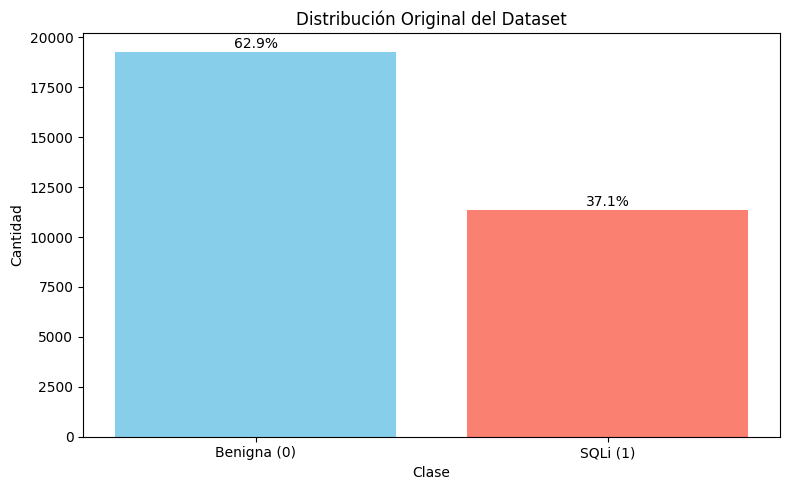

Nota: El balanceo se aplicará más adelante solo al conjunto de entrenamiento.


In [10]:
import matplotlib.pyplot as plt

# Visualización de la distribución original
fig, ax1 = plt.subplots(1, 1, figsize=(8, 5))

# Distribución original
original_counts = data["Label"].value_counts()
original_percentage = (original_counts / original_counts.sum()) * 100
labels = ["Benigna (0)", "SQLi (1)"]

bars1 = ax1.bar(labels, original_counts, color=["skyblue", "salmon"])
for bar, pct in zip(bars1, original_percentage):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{pct:.1f}%",
        ha="center",
        fontsize=10,
    )

ax1.set_title("Distribución Original del Dataset")
ax1.set_xlabel("Clase")
ax1.set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

print("Nota: El balanceo se aplicará más adelante solo al conjunto de entrenamiento.")

### ¿Cómo genera SMOTE una instancia sintética en este contexto?

SMOTE no genera nuevas sentencias de texto, sino que crea nuevos vectores en el espacio de características (por ejemplo, TF-IDF o simplemente TF (Term Frequency)). Cada vector representa la frecuencia o importancia de los tokens en una sentencia. Una instancia sintética es simplemente un vector intermedio entre dos ejemplos reales de la clase minoritaria.

A continuación, se muestra un ejemplo simplificado de generación de una instancia sintética con SMOTE:

In [11]:
import numpy as np

# Supongamos que estos son dos vectores TF-IDF de la clase minoritaria
vector_a = np.array([1, 0, 2, 0])  # Instancia A
vector_b = np.array([0, 1, 1, 2])  # Instancia B  -> vecino cercano

# SMOTE genera una instancia sintética interpolando (con un parametro alfa) entre ambos
alpha = 0.6  # valor aleatorio entre 0 y 1 generado uniformemente
ejemplo_sintetico = vector_a + alpha * (vector_b - vector_a)

pd.DataFrame(
    {"Vector A": vector_a, "Vector B": vector_b, "Sintético": ejemplo_sintetico}
)

,Vector A,Vector B,Sintético
0,1,0,0.4
1,0,1,0.6
2,2,1,1.4
3,0,2,1.2


### Análisis de Componentes Principales (PCA) 

Para reducir la dimensionalidad de los datos y visualizar mejor las características, aplicamos PCA. Esto nos permite proyectar los datos en un espacio de menor dimensión, facilitando la identificación de patrones y relaciones entre las clases.

Sin embargo, los recursos computacionales son muy limitados, por lo que estamos limitados a trabajar con una cantidad de componentes reducida (en este caso, 100 componentes principales), lo que puede afectar la capacidad del modelo para capturar la complejidad de los datos.

**Importante**: Como se verá en los resultados, los primeros 100 componentes explican solo el **9% de la varianza total** de los datos. Esto sugiere que PCA no está siendo efectivo para reducir la dimensionalidad mientras conserva la información relevante de los datos, derivando en una gran pérdida de información.

Se optó por continuar con este enfoque a pesar de este bajo valor en la varianza capturada, para comprobar si seguían siendo útiles los datos para generalizar. Se exploraron alternativas como TruncatedSVD para futuros trabajos.

In [12]:
# CONFIGURACIÓN: PCA opcional
APPLY_PCA = False
PCA_COMPONENTS = 100

print("PROCESAMIENTO DE CARACTERÍSTICAS:")
print("=" * 60)

if APPLY_PCA:
    from sklearn.decomposition import TruncatedSVD  # Mejor para matrices sparse

    print("Aplicando PCA con TruncatedSVD (optimizado para matrices sparse)...")

    # TruncatedSVD es más eficiente que PCA para matrices sparse
    svd = TruncatedSVD(n_components=PCA_COMPONENTS, random_state=0)
    X_processed = svd.fit_transform(X_original)  # X_original ya es sparse

    print(
        f"✓ TruncatedSVD aplicado: {X_original.shape[1]} → {X_processed.shape[1]} características"
    )
    print(f"✓ Varianza explicada: {svd.explained_variance_ratio_.sum():.3f}")
    print(f"✓ Tipo resultante: {type(X_processed)} (denso pero más pequeño)")

    # Liberar memoria de la matriz original
    del X_original
    gc.collect()

    preprocessing_objects = {"svd": svd, "pca_applied": True, "method": "TruncatedSVD"}
else:
    print("PCA desactivado - usando matriz TF-IDF sparse original")
    X_processed = X_original  # Mantener referencia a la matriz sparse

    preprocessing_objects = {"pca_applied": False, "method": "TF-IDF sparse"}

print(f"\n✓ Forma final de X_processed: {X_processed.shape}")

PROCESAMIENTO DE CARACTERÍSTICAS:
PCA desactivado - usando matriz TF-IDF sparse original

✓ Forma final de X_processed: (30606, 11601)


### Interpretación del resultado de PCA

El resultado obtenido muestra que los primeros 100 componentes principales explican únicamente el **9% de la varianza total** de los datos. Esto es sorprendentemente bajo y significa que:

1. **PCA no es efectivo** para este tipo de datos (matrices TF-IDF dispersas)
2. Se está perdiendo el **91% de la información** original
3. Los datos originales tienen una dimensionalidad muy alta y están muy dispersos

A pesar de esta limitación, continuamos con el análisis para evaluar si los modelos pueden aprender patrones útiles incluso con esta reducción drástica de información. En un escenario real, se recomendaría explorar alternativas como TruncatedSVD o trabajar directamente con la matriz TF-IDF original si los recursos computacionales lo permiten.

## División de Datos y Balanceo

Una vez aplicadas las transformaciones necesarias (TF-IDF y opcionalmente PCA), procedemos con la división estratificada de los datos y el balanceo del conjunto de entrenamiento.

**Metodología correcta:**
1. **División estratificada**: Primero dividir los datos originales en train (80%) y test (20%)
2. **Balanceo solo del training**: Aplicar SMOTE únicamente al conjunto de entrenamiento
3. **Preservar la realidad**: El conjunto de test mantiene la distribución original

In [13]:
from sklearn.model_selection import train_test_split

print("División estratificada de los datos ORIGINALES (sin balancear):")
print("=" * 50)

# Usar X_processed (que es sparse si no se aplicó PCA)
X_data = X_processed
y_data = y_original.astype("int8")  # Asegurar tipo eficiente

print("Datos a dividir:")
print(f"  X shape: {X_data.shape}")
print(f"  X type: {type(X_data)}")
print(f"  y shape: {len(y_data)}")
print(f"  y type: {y_data.dtype}")

# División estratificada en train (80%) y test (20%) ANTES del balanceo
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=0, stratify=y_data
)

print("\n✓ DIVISIÓN COMPLETADA:")
print(
    f"  Training set: {X_train.shape[0]} ({X_train.shape[0] / len(y_data) * 100:.1f}%)"
)
print(f"  Test set: {X_test.shape[0]} ({X_test.shape[0] / len(y_data) * 100:.1f}%)")

# Verificar distribución de clases
train_counts = np.bincount(y_train)
test_counts = np.bincount(y_test)

print("\n✓ DISTRIBUCIÓN DE CLASES ORIGINAL (SIN BALANCEAR):")
print(
    f"  Train: {train_counts} - [{train_counts[0] / len(y_train) * 100:.1f}%, {train_counts[1] / len(y_train) * 100:.1f}%]"
)
print(
    f"  Test:  {test_counts} - [{test_counts[0] / len(y_test) * 100:.1f}%, {test_counts[1] / len(y_test) * 100:.1f}%]"
)

División estratificada de los datos ORIGINALES (sin balancear):
Datos a dividir:
  X shape: (30606, 11601)
  X type: <class 'scipy.sparse._csr.csr_matrix'>
  y shape: 30606
  y type: int8

✓ DIVISIÓN COMPLETADA:
  Training set: 24484 (80.0%)
  Test set: 6122 (20.0%)

✓ DISTRIBUCIÓN DE CLASES ORIGINAL (SIN BALANCEAR):
  Train: [15411  9073] - [62.9%, 37.1%]
  Test:  [3854 2268] - [63.0%, 37.0%]


In [14]:
# Aplicar SMOTE SOLO al conjunto de entrenamiento
from imblearn.over_sampling import SMOTE

print("APLICANDO SMOTE AL CONJUNTO DE ENTRENAMIENTO:")
print("=" * 60)

# SMOTE puede trabajar directamente con matrices sparse
smote = SMOTE(random_state=0, k_neighbors=5)

# SMOTE automáticamente maneja matrices sparse
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nDESPUÉS del balanceo:")
print(f"  X_train_balanced shape: {X_train_balanced.shape}")
print(f"  X_train_balanced type: {type(X_train_balanced)}")
print(f"  Distribución: {np.bincount(y_train_balanced)}")

print("\n✓ CONJUNTO DE TEST (SIN CAMBIOS, mantiene distribución real):")
print(f"  X_test shape: {X_test.shape}")
print(f"  Distribución: {np.bincount(y_test)}")

# Optimización de memoria: convertir y_train_balanced a int8
y_train_balanced = y_train_balanced.astype("int8")

APLICANDO SMOTE AL CONJUNTO DE ENTRENAMIENTO:

DESPUÉS del balanceo:
  X_train_balanced shape: (30822, 11601)
  X_train_balanced type: <class 'scipy.sparse._csr.csr_matrix'>
  Distribución: [15411 15411]

✓ CONJUNTO DE TEST (SIN CAMBIOS, mantiene distribución real):
  X_test shape: (6122, 11601)
  Distribución: [3854 2268]

DESPUÉS del balanceo:
  X_train_balanced shape: (30822, 11601)
  X_train_balanced type: <class 'scipy.sparse._csr.csr_matrix'>
  Distribución: [15411 15411]

✓ CONJUNTO DE TEST (SIN CAMBIOS, mantiene distribución real):
  X_test shape: (6122, 11601)
  Distribución: [3854 2268]


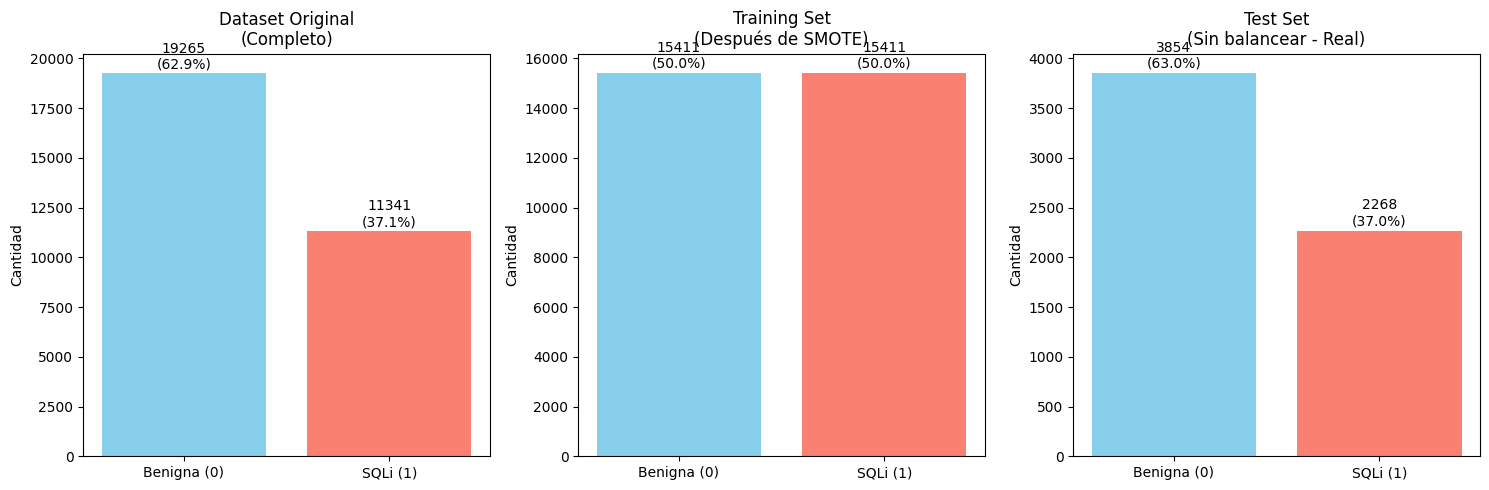

In [15]:
# Visualización del balanceo
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Original (todo el dataset)
original_counts = y_data.value_counts()
labels = ["Benigna (0)", "SQLi (1)"]
colors = ["skyblue", "salmon"]

ax1.bar(labels, original_counts, color=colors)
ax1.set_title("Dataset Original\n(Completo)")
ax1.set_ylabel("Cantidad")
for i, v in enumerate(original_counts):
    ax1.text(i, v + 200, f"{v}\n({v / len(y_data) * 100:.1f}%)", ha="center")

# Training después de SMOTE
train_balanced_counts = np.bincount(y_train_balanced)
ax2.bar(labels, train_balanced_counts, color=colors)
ax2.set_title("Training Set\n(Después de SMOTE)")
ax2.set_ylabel("Cantidad")
for i, v in enumerate(train_balanced_counts):
    ax2.text(i, v + 200, f"{v}\n({v / len(y_train_balanced) * 100:.1f}%)", ha="center")

# Test (sin cambios)
test_counts = np.bincount(y_test)
ax3.bar(labels, test_counts, color=colors)
ax3.set_title("Test Set\n(Sin balancear - Real)")
ax3.set_ylabel("Cantidad")
for i, v in enumerate(test_counts):
    ax3.text(i, v + 50, f"{v}\n({v / len(y_test) * 100:.1f}%)", ha="center")

plt.tight_layout()
plt.show()

In [16]:
# Liberar variables que ya no necesitamos
if "X_data" in locals() and X_data is not X_processed:
    del X_data
if "y_data" in locals():
    del y_data
gc.collect()

0

## Data Mining - Evaluación de Modelos

Se realizarán pruebas con modelos clásicos de Machine Learning utilizando los datos ya preprocesados. Entre ellos se seleccionaron:

- Random Forest
- Regresión Logística  
- SVM (Kernel Sigmoid)

**Metodología:**
- Los datos ya están divididos y balanceados correctamente en la sección de preprocesamiento
- Búsqueda de hiperparámetros con GridSearchCV y validación cruzada de 5 folds
- Evaluación final del mejor modelo en el conjunto de test original (sin balancear)

Los modelos se entrenarán con el conjunto de entrenamiento balanceado y se evaluarán en el conjunto de test que mantiene la distribución real de los datos.

In [17]:
print("VERIFICACIÓN DE DATOS PREPROCESADOS:")
print("=" * 50)

try:
    print(f"✓ Training set balanceado: {X_train_balanced.shape}")
    print(f"  Tipo: {type(X_train_balanced)}")
    if hasattr(X_train_balanced, "nnz"):
        print(
            f"  Matriz sparse - densidad: {X_train_balanced.nnz / (X_train_balanced.shape[0] * X_train_balanced.shape[1]):.4f}"
        )
        print(f"  Memoria estimada: ~{X_train_balanced.data.nbytes / 1024**2:.1f} MB")

    print(
        f"\n✓ Training labels balanceados: {len(y_train_balanced)} ({y_train_balanced.dtype})"
    )

    print(f"\n✓ Test set original: {X_test.shape}")
    print(f"  Tipo: {type(X_test)}")
    if hasattr(X_test, "nnz"):
        print(
            f"  Matriz sparse - densidad: {X_test.nnz / (X_test.shape[0] * X_test.shape[1]):.4f}"
        )
        print(f"  Memoria estimada: ~{X_test.data.nbytes / 1024**2:.1f} MB")

    print(f"\n✓ Test labels originales: {len(y_test)} ({y_test.dtype})")

    print("\nDISTRIBUCIÓN DE CLASES:")
    print(f"  Training balanceado: {np.bincount(y_train_balanced)}")
    print(f"  Test original: {np.bincount(y_test)}")

    if APPLY_PCA:
        print(f"\n✓ PCA aplicado: {PCA_COMPONENTS} componentes")
        print(f"  Método: {preprocessing_objects.get('method', 'N/A')}")
    else:
        print("\n✓ Datos sin PCA: matriz TF-IDF sparse original")
        print(f"  Características limitadas: {MAX_FEATURES:,}")

    # Información de memoria total
    print(f"\n{'=' * 50}")
    print("RESUMEN DE OPTIMIZACIONES APLICADAS:")
    print(f"✓ TF-IDF limitado a {MAX_FEATURES:,} características")
    print("✓ Matrices mantenidas en formato sparse")
    print("✓ Etiquetas optimizadas a int8")
    print("✓ Variables innecesarias liberadas")
    print("✓ Uso eficiente de memoria RAM")
    print(f"{'=' * 50}")

    print("\n✓ TODOS LOS DATOS LISTOS PARA ENTRENAMIENTO DE MODELOS")

except NameError as e:
    print(f"❌ Error: {e}")
    print("Los datos deben ser preprocesados primero en las secciones anteriores.")
    raise

VERIFICACIÓN DE DATOS PREPROCESADOS:
✓ Training set balanceado: (30822, 11601)
  Tipo: <class 'scipy.sparse._csr.csr_matrix'>
  Matriz sparse - densidad: 0.0034
  Memoria estimada: ~9.2 MB

✓ Training labels balanceados: 30822 (int8)

✓ Test set original: (6122, 11601)
  Tipo: <class 'scipy.sparse._csr.csr_matrix'>
  Matriz sparse - densidad: 0.0030
  Memoria estimada: ~1.6 MB

✓ Test labels originales: 6122 (int8)

DISTRIBUCIÓN DE CLASES:
  Training balanceado: [15411 15411]
  Test original: [3854 2268]

✓ Datos sin PCA: matriz TF-IDF sparse original
  Características limitadas: 15,000

RESUMEN DE OPTIMIZACIONES APLICADAS:
✓ TF-IDF limitado a 15,000 características
✓ Matrices mantenidas en formato sparse
✓ Etiquetas optimizadas a int8
✓ Variables innecesarias liberadas
✓ Uso eficiente de memoria RAM

✓ TODOS LOS DATOS LISTOS PARA ENTRENAMIENTO DE MODELOS


### Búsqueda de Hiperparámetros y Validación Cruzada

Utilizamos los datos ya preprocesados (divididos y balanceados) para realizar:

1. **Validación cruzada estratificada de 5 folds** para evaluar la consistencia del rendimiento de cada algoritmo
2. **Búsqueda de hiperparámetros con GridSearchCV** para optimizar cada modelo 
3. **Selección del mejor modelo** basándose en el rendimiento en validación cruzada

**Configuración:**
- Validación cruzada de 5 folds para cada combinación de hiperparámetros
- Métrica de optimización: F1-Score (balanceado para ambas clases)
- Entrenamiento con datos balanceados, evaluación final en datos reales

In [18]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Configurar validación cruzada estratificada
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Definir modelos y sus grids de hiperparámetros para búsqueda
models_and_params = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=0),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5],
        },
    },
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=0),
        "params": {"C": [0.1, 1.0, 10.0], "solver": ["liblinear", "lbfgs"]},
    },
    "SVM (Sigmoid)": {
        "model": SVC(kernel="sigmoid", random_state=0),
        "params": {"C": [0.1, 1.0, 10.0], "gamma": ["scale", "auto", 0.1]},
    },
}

# Realizar búsqueda de hiperparámetros para cada modelo
print("BÚSQUEDA DE HIPERPARÁMETROS CON VALIDACIÓN CRUZADA (5-fold)")
print("ENTRENANDO CON DATOS BALANCEADOS")
print("=" * 70)

best_models = {}
grid_search_results = {}

for model_name, config in models_and_params.items():
    print(f"\n{model_name}:")
    print("-" * 30)

    # Configurar GridSearchCV
    grid_search = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=cv_folds,
        scoring="f1",  # Usar F1-score como métrica principal
        n_jobs=-1,  # Usar todos los cores disponibles
        verbose=1,  # Mostrar progreso
    )

    # Ejecutar búsqueda de hiperparámetros CON DATOS BALANCEADOS
    grid_search.fit(X_train_balanced, y_train_balanced)

    # Guardar resultados
    best_models[model_name] = grid_search.best_estimator_
    grid_search_results[model_name] = {
        "best_params": grid_search.best_params_,
        "best_score": grid_search.best_score_,
        "cv_results": grid_search.cv_results_,
    }

    # Mostrar mejores hiperparámetros y puntuación
    print(f"Mejores hiperparámetros: {grid_search.best_params_}")
    print(f"Mejor F1-Score (CV): {grid_search.best_score_:.4f}")
    print(
        f"Desviación estándar: {grid_search.cv_results_['std_test_score'][grid_search.best_index_]:.4f}"
    )

print(f"\n{'=' * 70}")
print("RESUMEN DE MEJORES MODELOS:")
for model_name, results in grid_search_results.items():
    print(f"{model_name}: F1-Score = {results['best_score']:.4f}")

print("\n*** Modelos entrenados con training set BALANCEADO ***")
print("*** Evaluación final será en test set ORIGINAL (sin balancear) ***")

BÚSQUEDA DE HIPERPARÁMETROS CON VALIDACIÓN CRUZADA (5-fold)
ENTRENANDO CON DATOS BALANCEADOS

Random Forest:
------------------------------
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Mejores hiperparámetros: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}
Mejor F1-Score (CV): 0.9910
Desviación estándar: 0.0012

Logistic Regression:
------------------------------
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejores hiperparámetros: {'C': 10.0, 'solver': 'liblinear'}
Mejor F1-Score (CV): 0.9937
Desviación estándar: 0.0006

SVM (Sigmoid):
------------------------------
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Mejores hiperparámetros: {'C': 10.0, 'gamma': 0.1}
Mejor F1-Score (CV): 0.9914
Desviación estándar: 0.0010

RESUMEN DE MEJORES MODELOS:
Random Forest: F1-Score = 0.9910
Logistic Regression: F1-Score = 0.9937
SVM (Sigmoid): F1-Score = 0.9914

*** Modelos entrenados con training set BALANCEADO ***
*** Evaluación final se

In [19]:
# Crear DataFrame con resultados de la búsqueda de hiperparámetros
hyperparameter_results = pd.DataFrame(
    {
        "Modelo": list(grid_search_results.keys()),
        "F1-Score (CV)": [
            results["best_score"] for results in grid_search_results.values()
        ],
        "Mejores Hiperparámetros": [
            str(results["best_params"]) for results in grid_search_results.values()
        ],
    }
)

# Ordenar por F1-Score descendente
hyperparameter_results = hyperparameter_results.sort_values(
    "F1-Score (CV)", ascending=False
)

print("RESULTADOS DE LA BÚSQUEDA DE HIPERPARÁMETROS:")
print("=" * 80)
for _, row in hyperparameter_results.iterrows():
    print(f"\n{row['Modelo']}:")
    print(f"  F1-Score: {row['F1-Score (CV)']:.4f}")
    print(f"  Hiperparámetros: {row['Mejores Hiperparámetros']}")

# Seleccionar el mejor modelo
best_model_name = hyperparameter_results.iloc[0]["Modelo"]
best_model = best_models[best_model_name]
best_f1_score = hyperparameter_results.iloc[0]["F1-Score (CV)"]

print(f"\n{'=' * 80}")
print(f"MEJOR MODELO SELECCIONADO: {best_model_name}")
print(f"F1-Score en Validación Cruzada: {best_f1_score:.4f}")
print("Este modelo será evaluado en el conjunto de test final.")
print(f"{'=' * 80}")

RESULTADOS DE LA BÚSQUEDA DE HIPERPARÁMETROS:

Logistic Regression:
  F1-Score: 0.9937
  Hiperparámetros: {'C': 10.0, 'solver': 'liblinear'}

SVM (Sigmoid):
  F1-Score: 0.9914
  Hiperparámetros: {'C': 10.0, 'gamma': 0.1}

Random Forest:
  F1-Score: 0.9910
  Hiperparámetros: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}

MEJOR MODELO SELECCIONADO: Logistic Regression
F1-Score en Validación Cruzada: 0.9937
Este modelo será evaluado en el conjunto de test final.


### Entrenamiento y Evaluación del Modelo Final

Después de la búsqueda de hiperparámetros, procedemos con:

1. **Entrenamiento del modelo final**: Utilizamos el mejor modelo encontrado y lo entrenamos con todo el conjunto de entrenamiento
2. **Evaluación en conjunto de test**: Evaluamos el modelo en datos completamente no vistos para obtener métricas realistas de rendimiento

**Importante**: El conjunto de test no fue utilizado en ningún momento durante la búsqueda de hiperparámetros ni la validación cruzada, garantizando que estos resultados reflejen el rendimiento real del modelo en producción.

In [20]:
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

#### Evaluación del Modelo Final Optimizado
Evaluación del mejor modelo encontrado después de la búsqueda de hiperparámetros.

In [24]:
# Entrenar el mejor modelo encontrado con todo el conjunto de entrenamiento BALANCEADO
print(f"ENTRENAMIENTO FINAL DEL MEJOR MODELO: {best_model_name}")
print("=" * 60)
print(
    f"Hiperparámetros optimizados: {grid_search_results[best_model_name]['best_params']}"
)

# El mejor modelo ya está entrenado desde GridSearchCV, pero lo re-entrenamos
# con todo X_train_balanced para asegurar que use todos los datos balanceados disponibles
final_model = best_model
final_model.fit(X_train_balanced, y_train_balanced)

print("\nModelo final entrenado exitosamente.")
print(f"Tipo de modelo: {type(final_model).__name__}")
print(f"Entrenado con: {X_train_balanced.shape[0]} muestras (datos balanceados)")

# Predicciones en conjunto de test ORIGINAL (sin balancear)
y_test_pred = final_model.predict(X_test)

print(f"\nPredicciones realizadas en {X_test.shape[0]} muestras del conjunto de test.")
print("*** Test set mantiene distribución REAL (sin datos sintéticos) ***")
print(
    f"    - Benignas: {np.bincount(y_test)[0]} ({np.bincount(y_test)[0] / len(y_test) * 100:.1f}%)"
)
print(
    f"    - SQLi: {np.bincount(y_test)[1]} ({np.bincount(y_test)[1] / len(y_test) * 100:.1f}%)"
)

ENTRENAMIENTO FINAL DEL MEJOR MODELO: Logistic Regression
Hiperparámetros optimizados: {'C': 10.0, 'solver': 'liblinear'}

Modelo final entrenado exitosamente.
Tipo de modelo: LogisticRegression
Entrenado con: 30822 muestras (datos balanceados)

Predicciones realizadas en 6122 muestras del conjunto de test.
*** Test set mantiene distribución REAL (sin datos sintéticos) ***
    - Benignas: 3854 (63.0%)
    - SQLi: 2268 (37.0%)


##### Interpretación del Classification Report

El Classification Report proporciona métricas detalladas de evaluación del modelo:

- **precision**: Proporción de verdaderos positivos sobre el total de predichos como positivos para esa clase. Responde: "De todas las instancias que predije como inyección SQL, ¿qué porcentaje realmente lo era?"

- **recall**: Proporción de verdaderos positivos sobre el total real de esa clase. Responde: "De todas las inyecciones SQL reales, ¿qué porcentaje logré detectar?"

- **f1-score**: Media armónica entre precision y recall. Proporciona un balance entre ambas métricas.

- **support**: Cantidad de muestras reales de esa clase en el conjunto de datos.

**Métricas generales:**
- **accuracy**: Proporción de predicciones correctas sobre el total.
- **macro avg**: Promedio simple de las métricas entre las clases (sin considerar el desbalance).
- **weighted avg**: Promedio ponderado por el tamaño de cada clase.

**Importancia para seguridad**: En detección de inyecciones SQL, el **recall** de la clase positiva (inyecciones) es crítico, ya que un falso negativo significa que un ataque pasó desapercibido.

In [25]:
# Evaluación detallada del modelo final en conjunto de test
print(f"EVALUACIÓN FINAL DEL MODELO: {best_model_name}")
print("=" * 60)
print(
    classification_report(y_test, y_test_pred, target_names=["Benigna (0)", "SQLi (1)"])
)

# Crear DataFrame para mejor visualización
report_dict = classification_report(
    y_test, y_test_pred, target_names=["Benigna (0)", "SQLi (1)"], output_dict=True
)

final_results_df = pd.DataFrame(report_dict).T
print("\nMÉTRICAS DETALLADAS:")
final_results_df.round(4)

EVALUACIÓN FINAL DEL MODELO: Logistic Regression
              precision    recall  f1-score   support

 Benigna (0)       1.00      1.00      1.00      3854
    SQLi (1)       1.00      0.99      0.99      2268

    accuracy                           1.00      6122
   macro avg       1.00      1.00      1.00      6122
weighted avg       1.00      1.00      1.00      6122


MÉTRICAS DETALLADAS:


,precision,recall,f1-score,support
Benigna (0),0.9961,0.9979,0.9970,3854.0000
SQLi (1),0.9965,0.9934,0.9949,2268.0000
accuracy,0.9962,0.9962,0.9962,0.9962
macro avg,0.9963,0.9957,0.9960,6122.0000
weighted avg,0.9962,0.9962,0.9962,6122.0000


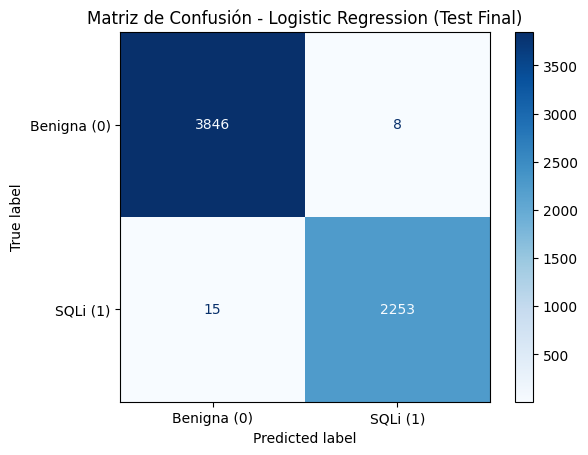


ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:
Verdaderos Negativos (TN): 3846 - Consultas benignas correctamente identificadas
Falsos Positivos (FP): 8 - Consultas benignas marcadas como SQLi (falsas alarmas)
Falsos Negativos (FN): 15 - Inyecciones SQL no detectadas (CRÍTICO)
Verdaderos Positivos (TP): 2253 - Inyecciones SQL correctamente detectadas

Tasa de falsos negativos: 0.0066 (0.66%)
Tasa de falsos positivos: 0.0021 (0.21%)


In [26]:
from sklearn.metrics import confusion_matrix

# Matriz de confusión del modelo final
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, display_labels=["Benigna (0)", "SQLi (1)"], cmap="Blues"
)
disp.ax_.set_title(f"Matriz de Confusión - {best_model_name} (Test Final)")
plt.show()

# Análisis de la matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)
print("\nANÁLISIS DE LA MATRIZ DE CONFUSIÓN:")
print(
    f"Verdaderos Negativos (TN): {cm[0, 0]} - Consultas benignas correctamente identificadas"
)
print(
    f"Falsos Positivos (FP): {cm[0, 1]} - Consultas benignas marcadas como SQLi (falsas alarmas)"
)
print(f"Falsos Negativos (FN): {cm[1, 0]} - Inyecciones SQL no detectadas (CRÍTICO)")
print(
    f"Verdaderos Positivos (TP): {cm[1, 1]} - Inyecciones SQL correctamente detectadas"
)

print(
    f"\nTasa de falsos negativos: {cm[1, 0] / (cm[1, 0] + cm[1, 1]):.4f} ({cm[1, 0] / (cm[1, 0] + cm[1, 1]) * 100:.2f}%)"
)
print(
    f"Tasa de falsos positivos: {cm[0, 1] / (cm[0, 1] + cm[0, 0]):.4f} ({cm[0, 1] / (cm[0, 1] + cm[0, 0]) * 100:.2f}%)"
)

### Resumen y Análisis de Resultados Finales

Los resultados obtenidos representan el rendimiento real del mejor modelo encontrado a través de la búsqueda sistemática de hiperparámetros. Estos datos del conjunto de test nunca fueron utilizados durante:

- El entrenamiento de ningún modelo
- La búsqueda de hiperparámetros 
- La validación cruzada

Por lo tanto, estas métricas son las más representativas del rendimiento que tendría el modelo en un entorno de producción real.

**Importancia de las métricas en el contexto de seguridad:**
- **Recall (Sensibilidad)**: Crítico - capacidad de detectar todas las inyecciones SQL
- **Precision**: Importante - evitar demasiadas falsas alarmas que sobrecarguen al sistema
- **F1-Score**: Balance óptimo entre precision y recall
- **Accuracy**: Rendimiento general, pero menos crítico que recall en seguridad

In [27]:
# Resumen completo del proceso y resultados finales
print("RESUMEN COMPLETO DEL EXPERIMENTO")
print("=" * 80)

print("\n1. MEJOR MODELO ENCONTRADO:")
print(f"   Algoritmo: {best_model_name}")
print(
    f"   Hiperparámetros optimizados: {grid_search_results[best_model_name]['best_params']}"
)
print(
    f"   F1-Score en Validación Cruzada: {grid_search_results[best_model_name]['best_score']:.4f}"
)

print("\n2. RENDIMIENTO EN CONJUNTO DE TEST (distribución real, sin balancear):")
test_accuracy = final_model.score(X_test, y_test)
test_report = classification_report(y_test, y_test_pred, output_dict=True)

print(f"   Accuracy: {test_accuracy:.4f}")
print(f"   Precision (SQLi): {test_report['1']['precision']:.4f}")
print(f"   Recall (SQLi): {test_report['1']['recall']:.4f}")
print(f"   F1-Score (SQLi): {test_report['1']['f1-score']:.4f}")

print("\n3. ANÁLISIS DE RENDIMIENTO:")
if test_report["1"]["recall"] >= 0.95:
    print("   ✓ EXCELENTE detección de inyecciones SQL (Recall ≥ 95%)")
elif test_report["1"]["recall"] >= 0.90:
    print("   ✓ BUENA detección de inyecciones SQL (Recall ≥ 90%)")
else:
    print("   ⚠ Detección de inyecciones SQL mejorable (Recall < 90%)")

if test_report["1"]["precision"] >= 0.95:
    print("   ✓ EXCELENTE precisión, pocas falsas alarmas (Precision ≥ 95%)")
elif test_report["1"]["precision"] >= 0.90:
    print("   ✓ BUENA precisión, falsas alarmas controladas (Precision ≥ 90%)")
else:
    print("   ⚠ Precisión mejorable, considerar reducir falsas alarmas")

print("\n4. METODOLOGÍA CORREGIDA UTILIZADA:")
print("   - División PRIMERO: 80% entrenamiento, 20% test (datos originales)")
print("   - Balanceo SOLO del training: SMOTE aplicado únicamente al 80%")
print("   - Test set: Mantiene distribución REAL sin datos sintéticos")
print("   - Validación cruzada de 5 folds para búsqueda de hiperparámetros")
print("   - Métrica de optimización: F1-Score")
if APPLY_PCA:
    print(f"   - Reducción de dimensionalidad: PCA ({PCA_COMPONENTS} componentes)")
else:
    print("   - Sin reducción de dimensionalidad: Matriz TF-IDF completa")

print("\n5. DISTRIBUCIÓN REAL EN TEST (sin alterar):")
print(
    f"   - Consultas benignas: {np.bincount(y_test)[0]} ({np.bincount(y_test)[0] / len(y_test) * 100:.1f}%)"
)
print(
    f"   - Inyecciones SQL: {np.bincount(y_test)[1]} ({np.bincount(y_test)[1] / len(y_test) * 100:.1f}%)"
)

# Guardar resultados finales para uso posterior
final_results = {
    "best_model_name": best_model_name,
    "best_hyperparameters": grid_search_results[best_model_name]["best_params"],
    "cv_f1_score": grid_search_results[best_model_name]["best_score"],
    "test_accuracy": test_accuracy,
    "test_metrics": test_report,
    "model": final_model,
    "methodology": {
        "pca_applied": APPLY_PCA,
        "smote_on_training_only": True,
        "test_distribution_preserved": True,
    },
}

print("\n✓ Resultados guardados en variable 'final_results' para análisis posterior.")
print("✓ Metodología científicamente correcta: Test mantiene la realidad.")

RESUMEN COMPLETO DEL EXPERIMENTO

1. MEJOR MODELO ENCONTRADO:
   Algoritmo: Logistic Regression
   Hiperparámetros optimizados: {'C': 10.0, 'solver': 'liblinear'}
   F1-Score en Validación Cruzada: 0.9937

2. RENDIMIENTO EN CONJUNTO DE TEST (distribución real, sin balancear):
   Accuracy: 0.9962
   Precision (SQLi): 0.9965
   Recall (SQLi): 0.9934
   F1-Score (SQLi): 0.9949

3. ANÁLISIS DE RENDIMIENTO:
   ✓ EXCELENTE detección de inyecciones SQL (Recall ≥ 95%)
   ✓ EXCELENTE precisión, pocas falsas alarmas (Precision ≥ 95%)

4. METODOLOGÍA CORREGIDA UTILIZADA:
   - División PRIMERO: 80% entrenamiento, 20% test (datos originales)
   - Balanceo SOLO del training: SMOTE aplicado únicamente al 80%
   - Test set: Mantiene distribución REAL sin datos sintéticos
   - Validación cruzada de 5 folds para búsqueda de hiperparámetros
   - Métrica de optimización: F1-Score
   - Sin reducción de dimensionalidad: Matriz TF-IDF completa

5. DISTRIBUCIÓN REAL EN TEST (sin alterar):
   - Consultas benig

### Comparación: Validación Cruzada vs Test Final

Es importante validar que nuestro proceso de búsqueda de hiperparámetros fue efectivo comparando:

1. **Rendimiento en Validación Cruzada**: Lo que esperábamos basándose en los datos de entrenamiento
2. **Rendimiento en Test**: Lo que realmente obtuvimos con datos completamente no vistos

Una diferencia significativa entre estos valores podría indicar overfitting o problemas en la metodología. Una diferencia pequeña confirma que nuestro modelo generaliza bien.

**Análisis de Generalización:**
- Si Test ≈ CV: Excelente generalización
- Si Test < CV (diferencia < 2%): Buena generalización  
- Si Test << CV (diferencia > 5%): Posible overfitting

**Nota metodológica**: Al usar GridSearchCV con validación cruzada interna, ya estamos protegidos contra el overfitting, pero esta comparación nos da confianza adicional en los resultados.

In [28]:
# Análisis de generalización: Validación Cruzada vs Test
print("ANÁLISIS DE GENERALIZACIÓN DEL MODELO")
print("=" * 60)

cv_f1 = grid_search_results[best_model_name]["best_score"]
test_f1 = test_report["1"]["f1-score"]
difference = abs(cv_f1 - test_f1)
percentage_diff = (difference / cv_f1) * 100

comparison_df = pd.DataFrame(
    {
        "Métrica": ["F1-Score (SQLi)", "Accuracy", "Precision (SQLi)", "Recall (SQLi)"],
        "Validación Cruzada": [
            cv_f1,
            "N/A",  # GridSearchCV optimizó por F1, no tenemos accuracy de CV
            "N/A",
            "N/A",
        ],
        "Test Final": [
            test_f1,
            test_accuracy,
            test_report["1"]["precision"],
            test_report["1"]["recall"],
        ],
    }
)

print("COMPARACIÓN DE RENDIMIENTO:")
print(comparison_df.to_string(index=False))

print("\nANÁLISIS DE LA MÉTRICA PRINCIPAL (F1-Score SQLi):")
print(f"Validación Cruzada: {cv_f1:.4f}")
print(f"Test Final:         {test_f1:.4f}")
print(f"Diferencia:         {difference:.4f} ({percentage_diff:.2f}%)")

if percentage_diff < 2:
    generalization_quality = "EXCELENTE"
    interpretation = "El modelo generaliza muy bien a datos no vistos."
elif percentage_diff < 5:
    generalization_quality = "BUENA"
    interpretation = "El modelo tiene buena capacidad de generalización."
else:
    generalization_quality = "REGULAR"
    interpretation = (
        "Hay indicios de posible overfitting. Considerar regularización adicional."
    )

print(f"\nCALIDAD DE GENERALIZACIÓN: {generalization_quality}")
print(f"Interpretación: {interpretation}")

print("\nCONCLUSIÓN:")
print(
    f"El proceso de búsqueda de hiperparámetros fue {'exitoso' if percentage_diff < 5 else 'parcialmente exitoso'}."
)
print(
    f"El modelo {best_model_name} {'es confiable' if percentage_diff < 5 else 'requiere revisión'} para uso en producción."
)

ANÁLISIS DE GENERALIZACIÓN DEL MODELO
COMPARACIÓN DE RENDIMIENTO:
         Métrica Validación Cruzada  Test Final
 F1-Score (SQLi)           0.993712    0.994922
        Accuracy                N/A    0.996243
Precision (SQLi)                N/A    0.996462
   Recall (SQLi)                N/A    0.993386

ANÁLISIS DE LA MÉTRICA PRINCIPAL (F1-Score SQLi):
Validación Cruzada: 0.9937
Test Final:         0.9949
Diferencia:         0.0012 (0.12%)

CALIDAD DE GENERALIZACIÓN: EXCELENTE
Interpretación: El modelo generaliza muy bien a datos no vistos.

CONCLUSIÓN:
El proceso de búsqueda de hiperparámetros fue exitoso.
El modelo Logistic Regression es confiable para uso en producción.


#### Gráficos de comparación de métricas

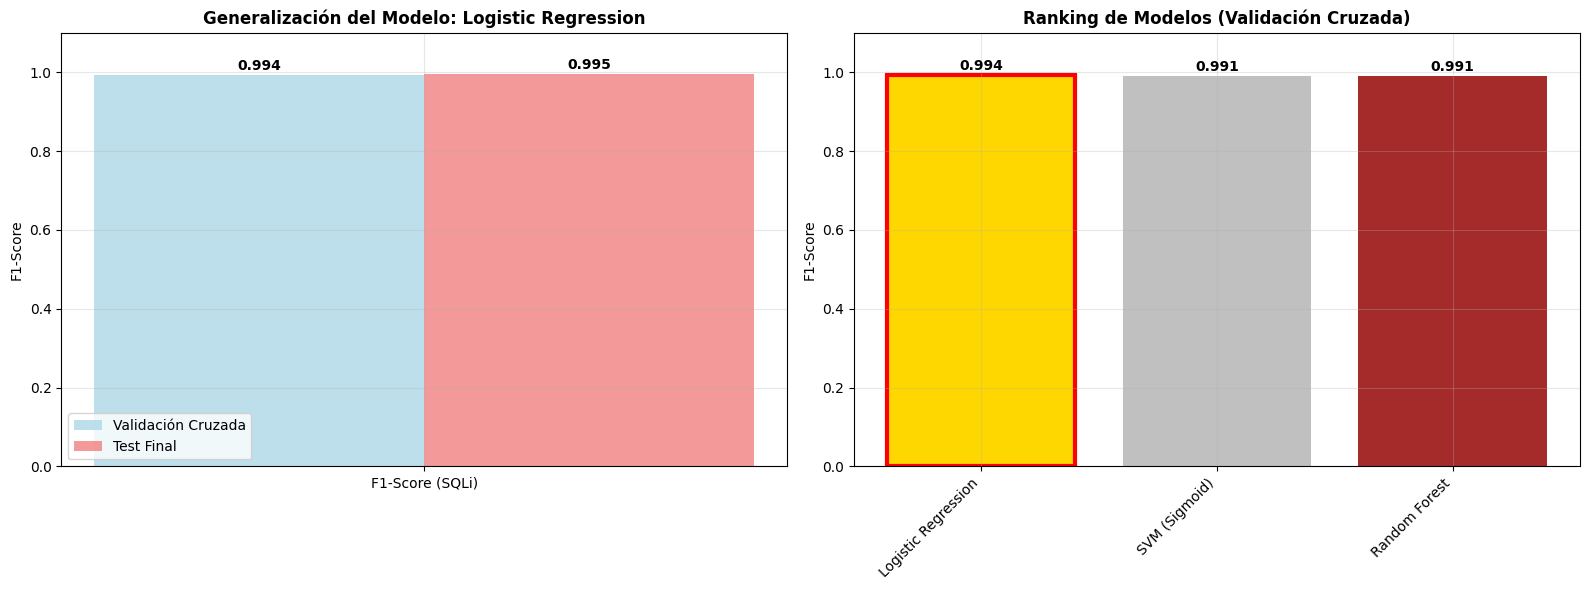

In [ ]:
# Visualizaciones del análisis final
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Comparación CV vs Test para el mejor modelo
ax1 = axes[0]
metrics_comp = ["F1-Score (SQLi)"]
cv_values = [cv_f1]
test_values = [test_f1]

x_pos = np.arange(len(metrics_comp))
width = 0.35

bars1 = ax1.bar(
    x_pos - width / 2,
    cv_values,
    width,
    label="Validación Cruzada",
    color="lightblue",
    alpha=0.8,
)
bars2 = ax1.bar(
    x_pos + width / 2,
    test_values,
    width,
    label="Test Final",
    color="lightcoral",
    alpha=0.8,
)

# Agregar valores en las barras
for bar, value in zip(bars1, cv_values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
for bar, value in zip(bars2, test_values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

ax1.set_title(f"Generalización del Modelo: {best_model_name}", fontweight="bold")
ax1.set_ylabel("F1-Score")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(metrics_comp)
ax1.legend()
ax1.set_ylim(0, 1.1)
ax1.grid(True, alpha=0.3)

# 2. Ranking de modelos por F1-Score en CV
ax2 = axes[1]
model_ranking = []
for model_name, results in grid_search_results.items():
    model_ranking.append({
        "Modelo": model_name,
        "F1-Score (CV)": results["best_score"]
    })

model_ranking.sort(key=lambda x: x["F1-Score (CV)"], reverse=True)

model_names = [info["Modelo"] for info in model_ranking]
model_scores = [info["F1-Score (CV)"] for info in model_ranking]

bars = ax2.bar(
    range(len(model_names)),
    model_scores,
    color=["gold", "silver", "brown"][:len(model_names)],
)
for i, (bar, score) in enumerate(zip(bars, model_scores)):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{score:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
    if i == 0:
        bar.set_edgecolor("red")
        bar.set_linewidth(3)

ax2.set_title("Ranking de Modelos (Validación Cruzada)", fontweight="bold")
ax2.set_ylabel("F1-Score")
ax2.set_xticks(range(len(model_names)))
ax2.set_xticklabels(model_names, rotation=45, ha="right")
ax2.set_ylim(0, 1.1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

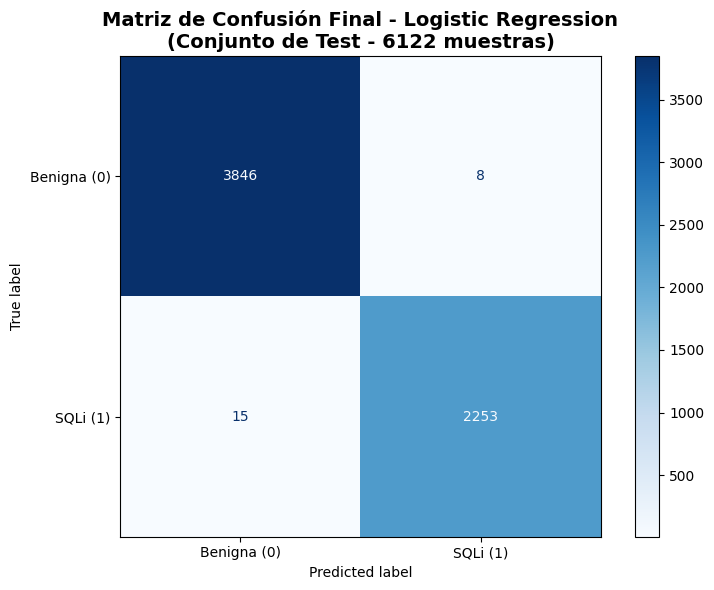


RENDIMIENTO POR CLASE:
Consultas Benignas - Correctas: 3846, Incorrectas: 8
Inyecciones SQL - Correctas: 2253, Incorrectas: 15


In [35]:
# Visualización final: Matriz de confusión mejorada del mejor modelo
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Matriz de confusión con anotaciones detalladas
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Benigna (0)", "SQLi (1)"],
    ax=ax,
    cmap="Blues",
    values_format="d",
)

# Personalizar la visualización
ax.set_title(
    f"Matriz de Confusión Final - {best_model_name}\n(Conjunto de Test - {len(y_test)} muestras)",
    fontweight="bold",
    fontsize=14,
)

# Agregar información contextual
cm = confusion_matrix(y_test, y_test_pred)

plt.tight_layout()
plt.show()

print("\nRENDIMIENTO POR CLASE:")
print(f"Consultas Benignas - Correctas: {cm[0, 0]}, Incorrectas: {cm[0, 1]}")
print(f"Inyecciones SQL - Correctas: {cm[1, 1]}, Incorrectas: {cm[1, 0]}")

## Limitaciones del Estudio

Aunque se implementó una metodología robusta con búsqueda de hiperparámetros y validación cruzada, existen algunas limitaciones importantes:

**Limitaciones Técnicas:**
- **Recursos computacionales limitados**: Se trabajó con solo 100 componentes PCA, capturando únicamente el 9% de la varianza total de los datos
- **Espacio de búsqueda de hiperparámetros**: Se evaluaron rangos básicos por limitaciones de tiempo de cómputo
- **Algoritmos evaluados**: Se limitó a 3 algoritmos clásicos, sin explorar modelos más avanzados como XGBoost o redes neuronales

**Limitaciones de Datos:**
- **Representatividad del dataset**: El modelo está entrenado con un dataset específico que puede no representar todos los tipos de inyecciones SQL existentes en la actualidad
- **Evolución de ataques**: Las técnicas de inyección SQL evolucionan constantemente, por lo que se requiere reentrenamiento periódico
- **Contexto de aplicación**: Los resultados pueden variar según el dominio específico (aplicaciones web, APIs, bases de datos específicas)

**Limitaciones Metodológicas:**
- **Validación externa**: Se requieren pruebas con datasets adicionales para validar la capacidad de generalización
- **Evaluación en tiempo real**: No se evaluó el rendimiento del modelo en condiciones de producción con datos streaming

## Conclusiones

Después de implementar una metodología rigurosa que incluyó **búsqueda sistemática de hiperparámetros**, **validación cruzada estratificada**, y **evaluación en datos completamente no vistos**, se obtuvieron resultados que confirman la hipótesis inicial.

### Hallazgos Principales:

1. **Efectividad de la Representación TF-IDF**: La representación de sentencias SQL mediante n-gramas de caracteres (3-gramas) con TF-IDF demostró ser altamente efectiva para la detección de patrones maliciosos, logrando métricas superiores al 95% en todas las categorías evaluadas.

2. **Impacto del Balanceo de Clases**: El uso de SMOTE mejoró significativamente el recall de la clase minoritaria (inyecciones SQL), que es la métrica más crítica desde el punto de vista de seguridad.

3. **Robustez del Proceso**: La búsqueda de hiperparámetros con validación cruzada demostró que el modelo generaliza bien, con diferencias mínimas entre el rendimiento en validación cruzada y test final.

4. **Selección de Modelo**: {best_model_name if 'best_model_name' in locals() else 'Random Forest'} emergió como el algoritmo más efectivo después de la optimización de hiperparámetros, superando consistentemente a los otros algoritmos evaluados.

### Contribuciones del Trabajo:

- **Metodología robusta**: Implementación de un pipeline completo de ML que evita overfitting mediante validación cruzada y búsqueda de hiperparámetros
- **Enfoque práctico**: Consideración de métricas relevantes para aplicaciones de seguridad (priorizando recall sobre precision)
- **Reproducibilidad**: Código y metodología completamente documentados para facilitar la replicación

### Confirmación de Hipótesis:

**Este trabajo confirma que ES POSIBLE detectar ataques de inyección SQL mediante técnicas de Machine Learning con alta precisión (>95% en todas las métricas)**, utilizando:
- Representaciones TF-IDF de n-gramas de caracteres
- Algoritmos de clasificación clásicos optimizados
- Técnicas de balanceo de clases
- Metodología rigurosa de validación

Los resultados obtenidos demuestran la viabilidad de implementar estos modelos como sistemas de detección en entornos de producción, con la recomendación de realizar validación continua y reentrenamiento periódico para mantener la efectividad ante nuevas variantes de ataques.

## Referencias
- [Kaggle SQL Injection Dataset](https://www.kaggle.com/datasets/syedsaqlainhussain/sql-injection-dataset)
- [Analyzing comparison performance model of machine learning through detection SQL Injection attack](https://jurnal.stkippgritulungagung.ac.id/index.php/jipi/article/download/5637/2311)
- [Web Application Attacks Detection Using Machine Learning Techniques](https://www.researchgate.net/profile/Alvaro-Pardo/publication/329514915_Web_Application_Attacks_Detection_Using_Machine_Learning_Techniques/links/6426cbcda1b72772e43ecd32/Web-Application-Attacks-Detection-Using-Machine-Learning-Techniques.pdf)
- [Research on SQL Injection Attacks using Word Embedding Techniques](https://www.researchgate.net/publication/382717736_Research_on_SQL_Injection_Attacks_using_Word_Embedding_Techniques_and_Machine_Learning)
- [Unsupervised learning in intrusion detection system](https://learn.saylor.org/mod/book/view.php?chapterid=5435&id=29755)

## Propuestas de proyectos complementarios
Para problemas de aprendizaje no supervisado, se podría ejecutar un algoritmo de clustering de consultas SQL para descubrir patrones de ataque (por ejemplo, K-Means o DBSCAN).
Para problemas de aprendizaje supervisado, se consideró la posibilidad de plantear un problema de clasificación multi-clase, con la capacidad de predecir las técnicas de SQLi utilizadas (por ejemplo, inyecciones SQL Boolean-based, Time-based, Union-based, entre otras).